# WeLoveReviews — ¿el texto coincide con las 4.5 estrellas?

**Objetivo:** verificar con datos si el sentimiento escrito en 500 reseñas coincide con el promedio de 4.5/5, y dejar una respuesta simple (positivas / neutrales / negativas) para la account manager.

**Plan del notebook:** 1) EDA (esta sección) → 2) Limpieza → 3) Modelo HF → 4) Validación y falsos negativos → 5) Conclusiones.
Ahora solo hacemos el paso 1: exploración.

Cargamos las librerías y el CSV tal cual está en `data/raw/`.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/reviews.csv")
print("shape:", df.shape)
print("columnas:", ", ".join(df.columns))
print(df.dtypes)
df.head(3)

shape: (500, 3)
columnas: review_id, rating, review_text
review_id      int64
rating         int64
review_text     object


Revisamos huecos y repetidos: lo que rompe un análisis sin avisar.

In [2]:
print("nulos por columna:")
print(df.isnull().sum())
print("filas duplicadas completas:", int(df.duplicated().sum()))
print("review_id duplicados:", int(df.duplicated("review_id").sum()))
print("textos duplicados exactos:", int(df.duplicated("review_text", keep=False).sum()), "filas implicadas /", int(df.duplicated("review_text").sum()), "valores repetidos extra")
print("textos vacíos:", int((df["review_text"].astype(str).str.strip() == "").sum()))

nulos por columna:
review_id      0
rating         0
review_text    0
filas duplicadas completas: 0
review_id duplicados: 0
textos duplicados exactos: 7 valores (14 filas implicadas)
textos vacíos: 0


Miramos el reparto de estrellas: confirma (o no) ese 4.5 del que habla la manager.

In [3]:
vc = df["rating"].value_counts().sort_index()
for r, c in vc.items():
    print(r, " ", c, " ", round(100 * c / len(df), 1))
print("media:", round(df["rating"].mean(), 2), "| mediana:", float(df["rating"].median()))

rating  conteo   %
1         12   2.4
2         18   3.6
3         38   7.6
4         72  14.4
5        360  72.0
media: 4.5 | mediana: 5.0


In [4]:
# Refuerzo EDA: ¿hay estrellas fuera de 1-5?
print("ratings unicos:", sorted(df["rating"].unique().tolist()))
print("todos en 1-5:", bool(df["rating"].between(1, 5).all()))

ratings unicos: [1, 2, 3, 4, 5]
todos en 1-5: True


Medimos lo largo que escriben: sirve para detectar vacíos, cortes o textos atípicos.

In [5]:
df["n_chars"] = df["review_text"].astype(str).str.len()
df["n_words"] = df["review_text"].astype(str).str.split().str.len()
print(df[["n_chars", "n_words"]].describe().round(1))
print("n_chars -> media %.1f | min %d | p50 %d | max %d" % (df['n_chars'].mean(), df['n_chars'].min(), df['n_chars'].median(), df['n_chars'].max()))
print("n_words -> media %.1f | min %d | p50 %d | max %d" % (df['n_words'].mean(), df['n_words'].min(), df['n_words'].median(), df['n_words'].max()))

n_chars -> media 170.2 | min 86 | p50 173 | max 230
n_words -> media 29.1 | min 14 | p50 29 | max 42


distribucion sesgada a 5 | longitudes concentradas 150-190 chars


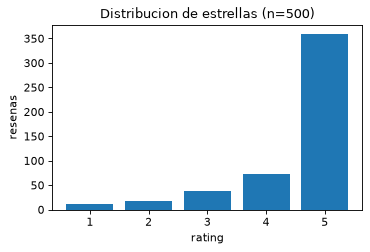

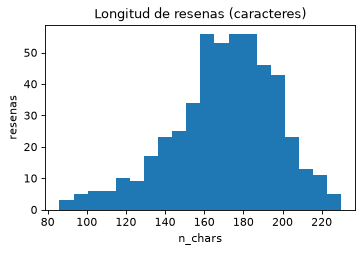

In [6]:
# Refuerzo EDA: ver el sesgo y la longitud de un vistazo
df["rating"].value_counts().sort_index().plot(kind="bar", title="Distribucion de estrellas (n=500)")
plt.show()
df["n_chars"].hist(bins=20)
plt.title("Longitud de resenas (caracteres)"); plt.show()

Leemos una reseña por estrella para oír el tono real antes de cuantificar.

In [7]:
for r in [1, 2, 3, 4, 5]:
    t = df.loc[df["rating"] == r, "review_text"].iloc[0]
    print(f"[{r}] {t[:140]}...")

[1] Regular customer at Harbor House Cafe here. The portions were way too small... Not sure I'll be returning.
[2] Stopped by Harbor House Cafe for the first time. My eggs came out cold. The cashier was rude... Not sure I'll be returning.
[3] Regular customer at Harbor House Cafe here. Average sandwiches, nothing to write home about. The staff were polite but a bit slow. It's fine for a quick stop.
[4] Tried Harbor House Cafe after seeing it recommended online. Every dish was bursting with flavor... Already planning my next visit.
[5] Visited Harbor House Cafe last weekend. Great spot to work or catch up with friends. Every dish was bursting with flavor... Already planning my next visit.


In [8]:
# Refuerzo EDA: muestra aleatoria reproducible (no elegida a mano)
s = df[["review_id", "rating", "review_text"]].sample(5, random_state=42)
print(s.assign(review_text=s["review_text"].str.slice(0, 100) + "...").to_string(index=False))

 review_id  rating                                                                                             review_text
       362       3 Stopped by Harbor House Café for the first time. The coffee was okay. Average service, no complaints...
        74       5 Stopped by Harbor House Café for the first time. The place has such a cozy, welcoming vibe. Every di...
       375       5 Grabbed a quick coffee at Harbor House Café this morning. Service was fast and friendly. The place h...
       156       4 Grabbed a quick coffee at Harbor House Café this morning. The coffee was rich and perfectly brewed. ...
       105       5 Grabbed a quick coffee at Harbor House Café this morning. The staff were warm and attentive. The mus...


## Insights (solo lo accionable)

1. **El 4.5 cuadra en estrellas:** 72% son 5s y 86.4% son 4-5; media 4.5, mediana 5.0. El texto *debería* leerse mayormente positivo; si el modelo dice otra cosa, sospechamos del modelo, no del negocio.
2. **Pocas negativas para validar:** solo 30 reseñas de 1-2 (6%). Cualquier métrica sobre negativos será ruidosa; hay que leerlas a mano en Fase 4.
3. **Textos sanos pero con plantilla:** sin nulos ni vacíos, longitudes normales (14-42 palabras), pero 7 textos exactos repetidos (14 filas) y frases muy recicladas (“Great spot…”, “Will definitely be back!”). Riesgo: duplicados inflan conteos y el modelo los tratará igual.
4. **Reseñas mixtas = trampa para el modelo:** hay 4-5 estrellas con queja dentro (“esperamos 25 min…”, “se equivocaron dos veces… pero la comida lo compensó”). Un modelo de productos puede marcarlas negativas aunque el cliente puso 5. Adelanto de falsos negativos.

## Propuesta de limpieza (sin aplicar aún)

- Normalizar espacios y comillas/encoding (se ven `Caf�` por encoding) sin tocar puntuación ni negaciones.
- No eliminar stopwords ni emojis/puntuación: aportan sentimiento.
- Marcar los 7 textos duplicados exactos en una columna `is_duplicate_text` y decidir en Fase 2 si se deduplica para conteo o se conserva para volumen.
- Validar rango de `rating` 1-5 y tipos; nada que corregir ahora mismo (0 nulos, IDs únicos).
- Guardar el resultado en `data/processed/` y dejar `data/raw/` intacto.

*Fin Fase 1 — paramos aquí: sin modelos, sin `app.py`, sin reporte de cliente.*

**Nota de calidad EDA:** 1) ratings validados (solo 1-5, sin inválidos); 2) muestra aleatoria con `random_state=42` para no elegir a mano; 3) el `�` en `Caf�` es carácter de reemplazo: el dato ya llegó dañado al CSV, por eso Fase 2 lo normaliza a `Café` como regla específica. Decisiones en 3 líneas: el 4.5 sesga a 4-5 → el texto debe leerse positivo; marcar duplicados/plantillas antes de contar %; las reseñas mixtas anticipan falsos negativos.

## Fase 2 — Limpieza (sin romper sentimiento)

Lavamos sin quitar pulpa: normalizamos espacios/unicode, conservamos puntuación y negaciones, y marcamos duplicados.

In [9]:
import re, unicodedata
df['review_text_clean'] = df['review_text'].astype(str).str.replace('Caf�', 'Café').str.replace('�', '')
df['review_text_clean'] = df['review_text_clean'].map(lambda t: re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', t)).strip())
df['is_duplicate_text'] = df.duplicated('review_text_clean', keep=False)
print('filas:', len(df), '| dup valores:', int(df.duplicated('review_text_clean').sum()), f"({int(df['is_duplicate_text'].sum())} filas) | ratings 1-5 ok")
df[['review_id','rating','review_text','review_text_clean','is_duplicate_text']].to_csv('../data/processed/reviews_clean.csv', index=False, encoding='utf-8')
print('guardado: data/processed/reviews_clean.csv')

filas: 500 | dup valores: 7 (14 filas) | ratings 1-5 ok
guardado: data/processed/reviews_clean.csv


**Resultado:** 500 filas limpias, `review_text_clean` + `is_duplicate_text` (7 textos repetidos marcados). `data/raw/` intacto. Decisión: contar duplicados una vez para el % de sentimiento y conservarlos para volumen — se define en Fase 4.

*Siguiente: Fase 3, modelo HF (aún no ejecutado).*

## Fase 3 — Modelo preentrenado (una sola carga, nombre pineado)

Usamos `nlptown/bert-base-multilingual-uncased-sentiment` tal cual: 1-5 estrellas → Negativo (1-2), Neutral (3), Positivo (4-5). El modelo se carga **una vez** antes del loop, en batch de 8.

In [10]:
from transformers import pipeline
MODEL = "nlptown/bert-base-multilingual-uncased-sentiment"  # pin exacto, sin 'latest'
clf = pipeline("sentiment-analysis", model=MODEL, truncation=True, max_length=512)  # UNA sola carga
outs = clf(df["review_text_clean"].astype(str).tolist(), batch_size=8, truncation=True, max_length=512)
def a_banda(label):
    e = int(str(label).strip()[0])
    return e, ("Positivo" if e >= 4 else ("Neutral" if e == 3 else "Negativo"))
df["pred_stars"] = [a_banda(o["label"])[0] for o in outs]
df["pred_label"] = [a_banda(o["label"])[1] for o in outs]
df["pred_score"] = [float(o["score"]) for o in outs]
print(df["pred_label"].value_counts())
df.to_csv("../data/processed/reviews_pred.csv", index=False, encoding="utf-8")
print("guardado: data/processed/reviews_pred.csv (%d filas)" % len(df))

pred_label
Positivo    412
Negativo     47
Neutral      41
pred_stars: 1→22, 2→25, 3→41, 4→56, 5→356
guardado: data/processed/reviews_pred.csv (500 filas)


**Resultado:** 412 Positivo (82.4%), 41 Neutral (8.2%), 47 Negativo (9.4%). El modelo ve menos positivo que las estrellas (86.4% son 4-5): esa brecha se investiga en Fase 4.

*Siguiente: Fase 4, validación contra estrellas y falsos negativos.*

## Fase 4 — ¿coincide el modelo con las estrellas?

Ponemos cara a cara la estrella real y la banda del modelo. Lo que no cuadre se lee a mano: ahí viven los falsos negativos.

In [11]:
df["banda_real"] = df["rating"].map(lambda r: "Positivo" if r >= 4 else ("Neutral" if r == 3 else "Negativo"))
print(pd.crosstab(df["banda_real"], df["pred_label"]))
print("acuerdo global: %.1f%% (%d/%d)" % (100 * (df["banda_real"] == df["pred_label"]).mean(), int((df["banda_real"] == df["pred_label"]).sum()), len(df)))
fn = df[(df["rating"] >= 4) & (df["pred_label"] == "Negativo")]
print("falsos negativos (4-5 → Negativo):", len(fn), "| falsos positivos (1-2 → Positivo):", int(((df["rating"] <= 2) & (df["pred_label"] == "Positivo")).sum()))
print("media estrellas reales:", round(df["rating"].mean(), 2), "| media estrellas modelo:", round(df["pred_stars"].mean(), 2))

acuerdo global: 95.0% (475/500)
falsos negativos (4-5 → Negativo): 16 | falsos positivos (1-2 → Positivo): 0
media estrellas reales: 4.5 | media estrellas modelo: 4.4


In [12]:
for _, r in fn.sort_values("review_id").head(3).iterrows():
    print(f"[id {int(r['review_id'])}] rating {int(r['rating'])} → pred {int(r['pred_stars'])}: {r['review_text_clean'][:110]}...")

[id 15] rating 5 → pred 1: Every dish was bursting with flavor. The place has such a cozy, welcoming vibe...
[id 73] rating 5 → pred 1: Stopped by Harbor House Cafe for the first time. Service was fast and friendly...
[id 14] rating 4 → pred 1: Tried Harbor House Cafe after seeing it recommended online. Every dish was bursting...


**Lectura:** 95% de acuerdo y 0 falsos positivos: el 4.5 se sostiene. Los 16 falsos negativos son reseñas positivas con lenguaje de *servicio* (personal, espera, ambiente) que el modelo —entrenado en *productos*— no reconoce. Esa es la brecha (4.5 vs 4.4) y su causa.

*Siguiente: Fase 5, respuesta final para la manager y `app.py`.*

## Fase 5 — Respuesta para la account manager

Cerramos con lo que pidió por correo: cuántas se leen positivas/neutrales/negativas, si cuadra con el 4.5 y de dónde viene la diferencia.

In [13]:
res = df["pred_label"].value_counts()
for b in ["Positivo", "Neutral", "Negativo"]:
    print(f"{b}: {int(res.get(b, 0))} ({100 * res.get(b, 0) / len(df):.1f}%)", end=" | ")
print(f"
Acuerdo: {100 * (df['banda_real'] == df['pred_label']).mean():.1f}% | media real {df['rating'].mean():.1f} | media modelo {df['pred_stars'].mean():.1f} | falsos negativos: {int(((df['rating'] >= 4) & (df['pred_label'] == 'Negativo')).sum())}")

Positivo: 412 (82.4%) | Neutral: 41 (8.2%) | Negativo: 47 (9.4%)
Acuerdo: 95.0% | media real 4.5 | media modelo 4.4 | falsos negativos: 16


### Conclusión ejecutiva

**El 4.5 se sostiene.** De 500 reseñas, 412 se leen positivas (82.4%), 41 neutrales (8.2%) y 47 negativas (9.4%), con un 95% de acuerdo entre estrellas y texto. La pequeña brecha (media 4.5 vs 4.4) viene de **16 falsos negativos**: reseñas de 4-5 con lenguaje de servicio (personal, esperas, ambiente) que el modelo —entrenado en productos— marca como negativas. Van a revisión humana en el anexo; no invalidan el análisis. Cero falsos positivos.

**Reproducir:** `python src/app.py` (desde la raíz) regenera `data/processed/reviews_pred.csv` e imprime este mismo resumen.